# Dynamics of simple maps

[Moreno Marzolla](https://www.moreno.marzolla.name/) (see credits at the end).

Writte in March 2026. 

Last modified March 2026.

---

In this notebook we will explore the dynamic of functions in one dimension. We will see that even simple functions can have a very complex behavior.

## Iterating functions

Let us consider a function $f : \mathbb{R} \rightarrow \mathbb{R}$. We want to understand what happens if we iterate $f$, i.e., we take an initial value $x_0$, then apply $f$ to get $f(x_0)$, then apply $f$ again to get $f(f(x_0))$ and so on. 

The sequence

\begin{align*}
x_0 & \\
x_1 &= f(x_0) \\
x_2 &= f(x_1) = f(f(x_0)) = f^2(x_0) \\
x_3 &= f(x_2) = f(f(f(x_0))) = f^3(x_0) \\
\ldots\\
x_{n+1} &= f(x_n) = f^{n+1}(x_0) \\
\ldots\\
\end{align*}

is called the _forward orbit_ of $x_0$ under function $f$. Note that $f^n(x_0)$ denotes application of $f$ $n$ times, while $f(x_0)^n$ is the value $f(x_0)$ raised to the $n$-th power.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
import itertools as it

Since we are working with iterates of a function $f$, it is useful to define a Python generator `iterate(f,x0)` that produces the infinite sequence $x_0, f(x_0), f^2(x_0), \ldots$.

In [21]:
def iterate(f, x0):
    while True:
        yield(x0)
        x0 = f(x0)

Then we define the function `orbit(f, x0, n)` that returns the first $n$ elements of the orbit of $x_0$ produced by function $f$. `islice(g, n)` is a higher-order Python function that accepts as parameter a generator `g` and returns an iterator over the first $n$ items produced by `g`. In our case, the generator is `iterate(f, x0)`.

In [22]:
def orbit(f, x0, n):
    return list(it.islice(iterate(f,x0), n))

We can now easily compute, say, the first 10 elements of the orbit of $x_0 = 0.5$ under function $f(x) = x^2$.

In [23]:
orbit(lambda x: x**2, 0.5, 10)

[0.5,
 0.25,
 0.0625,
 0.00390625,
 1.52587890625e-05,
 2.3283064365386963e-10,
 5.421010862427522e-20,
 2.938735877055719e-39,
 8.636168555094445e-78,
 7.458340731200207e-155]

As can be expected, the orbit converges towards zero.

> **Exercise**. Is 0 the only limiting value for the orbits of $f(x) = x^2$?

> **Exercise**. Compute the orbit of $x_0 = 0.5$ under repeated application of the following functions:
>
> 1. $x^2-1$
> 2. $-x^2+1$
> 3. $2x(1-x)$
> 4. $3.8x(1-x)$
> 5. $\sin(x)$
>
> You may want to plot the sequence of values using `plt.plot(...)`.

## Fixed points

The fixed point(s) of a function $f$ are the solutions of the equation $f(x) = x$. In some cases it is possible to solve the equation quite easily. If this is not possible, there is a simple graphical way: overlap the plot of $y = f(x)$ and the bisector $y = x$. The intersection of these two graphs are the fixed points.

In [24]:
def plot_fixed_points(f, xlim = (0,1), ylim = (0,1), title = None):
    """ 
    Plot function f:[0,1]->[0,1] overlapped with the bisector y=x 
    """
    x = np.linspace(xlim[0], xlim[1], 200)
    fx = [f(t) for t in x]
    plt.plot(x, fx, 'k')
    plt.plot(x, x, 'c')
    plt.axvline(0)
    plt.axhline(0)
    plt.grid(visible = True)
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title(title)

For example, the fixed points of $f(x) = x^2$ are $x=0,1$ and can be found by solving $x^2 = x$. Indeed, graphical analysis confirms:

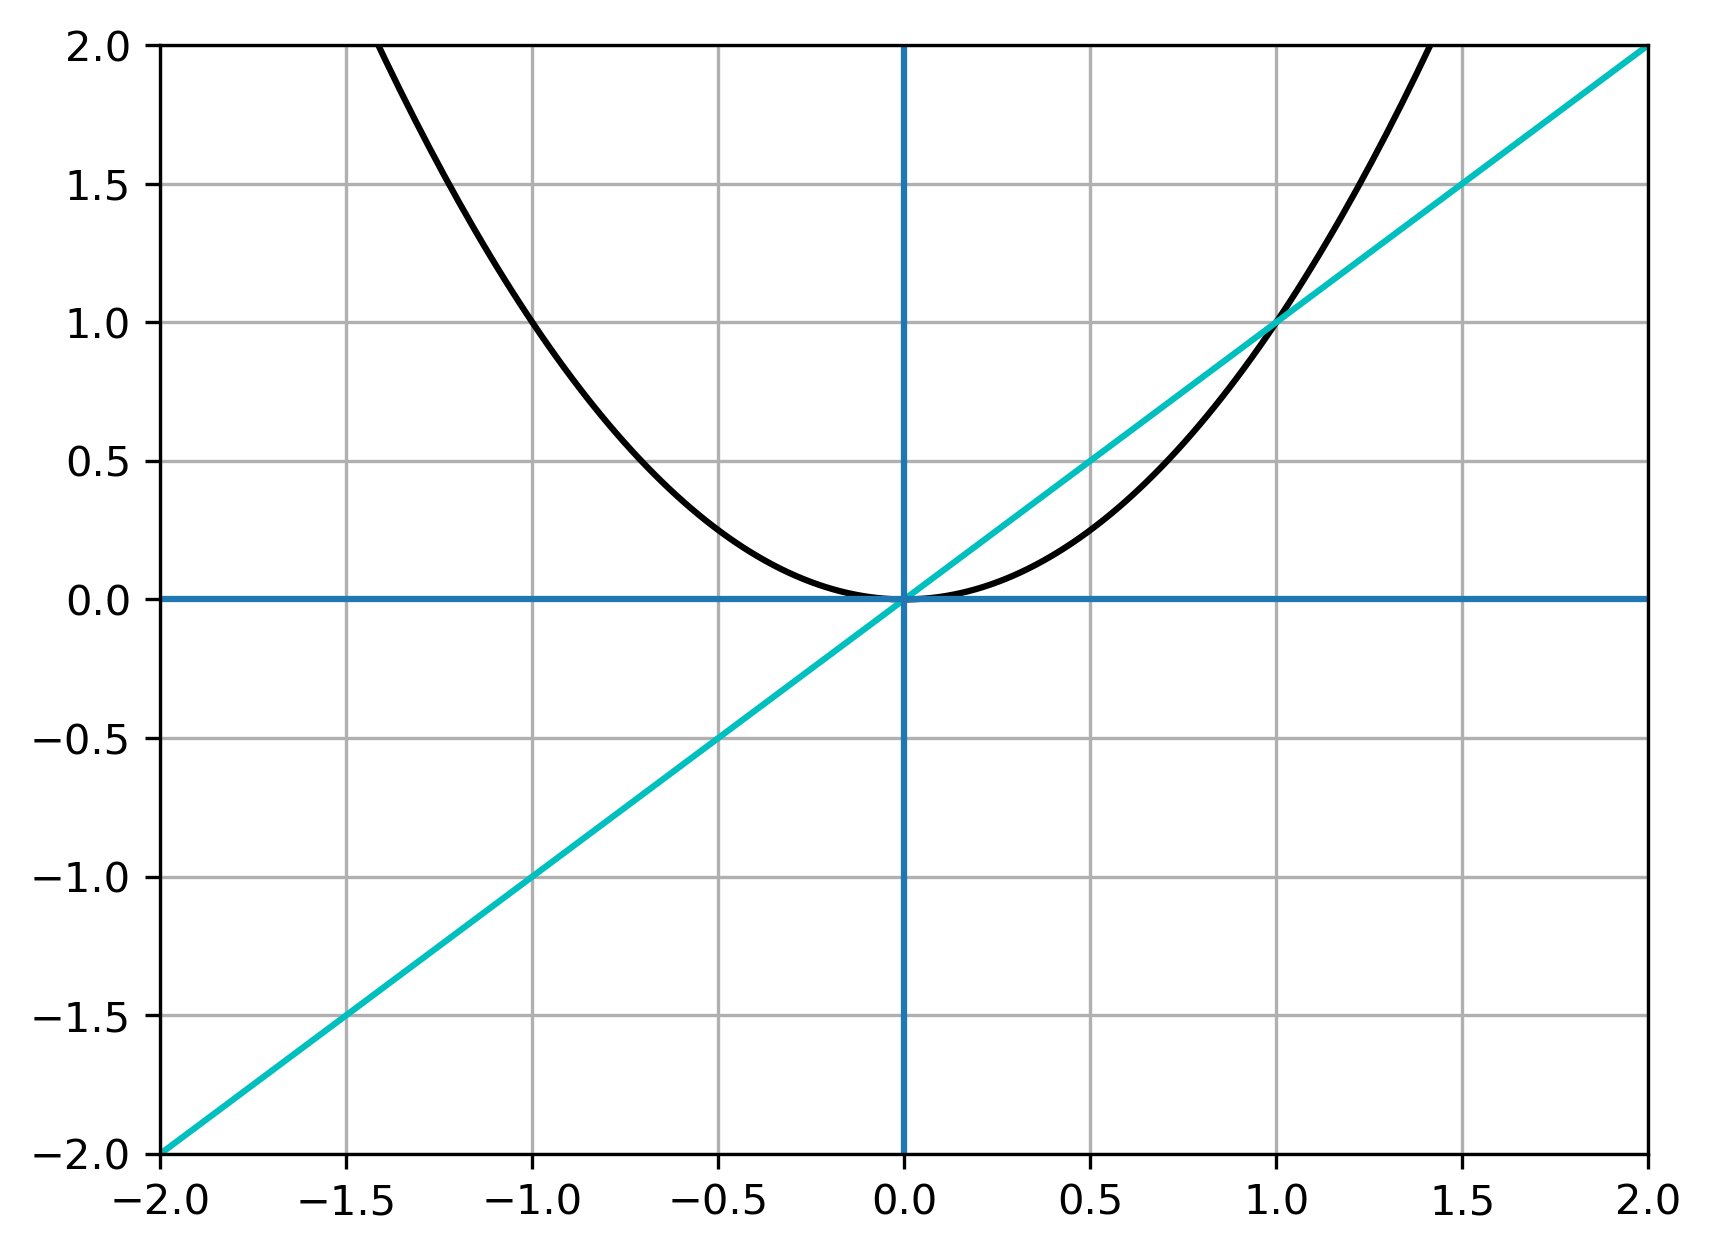

In [25]:
def f(x):
    return x**2

plot_fixed_points(f, xlim=(-2,2), ylim=(-2,2))

> **Exercise**. Use graphical analysis to find the fixed points of the following functions; assume $\mathbb{R}$ as the domain and codomain.
>
> 1. $2x+1$
> 2. $x^2$
> 3. $x^2-2$
> 4. $x^3$

What happens to the orbits of points that are near to the fixed points? Let us try with $x_0 = 1.1$; we observe that the orbit quickly diverges towards infinity.

In [26]:
orbit(f, 1.1, 10)

[1.1,
 1.2100000000000002,
 1.4641000000000004,
 2.143588810000001,
 4.594972986357221,
 21.1137767453526,
 445.7915684525922,
 198730.12250342217,
 39493661590.22518,
 1.5597493058032278e+21]

On the other hand, the orbit of $x_0 = 0.9$ converges towards zero.

In [27]:
orbit(f, 0.99, 10)

[0.99,
 0.9801,
 0.96059601,
 0.92274469442792,
 0.8514577710948754,
 0.7249803359578533,
 0.5255964875255618,
 0.276251667699208,
 0.07631498390659364,
 0.0058239767686636456]

We say that $x=1$ is a _repelling fixed point_, meaning that the orbits of nearby points "go away". On the other hand, $x=0$ is an _attracting fixed point_, since the orbits of bearby points converge towards zero. 

The _cobweb plot_ is a graphical approach to study the orbits of point of one-dimensional functions. Start by plotting the function $y = f(x)$ and the bisector $y=x$. To visualize the orbit of some initial value $x_0$, do the following:

1. Find the point $x_0$ on the horizontal axis.
2. Draw a vertical segment to the function.
3. Draw a horizontal segment to the diagonal.
4. Repeat from 2.

In [28]:
def cobweb(f, x0, n, xlim=(0,1), ylim=(0,1), title = None):
    """
    Draw the cobweb plot for function f:[0,1]->[0,1], starting with
    initial value x_0. Iterate the process n times.
    """
    plot_fixed_points(f, xlim, ylim, title)
    t = np.linspace(xlim[0], xlim[1], 100)
    ft = [f(x) for x in t]
    x, y = x0, 0
    plt.plot([x], [y], 'ob', ms=5)
    try:
        for i in range(n):
            #a = ((i+1)/n)**1.2
            plt.plot([x, x], [y, f(x)], 'b', lw=1)
            plt.plot([x, f(x)], [f(x), f(x)], 'b', lw=1)
            x,y = f(x),f(x)
    except:
        pass # ignore errors such as overflow
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.title(title)    

Let us visualize the orbits of $0.9$ and $1.1$.

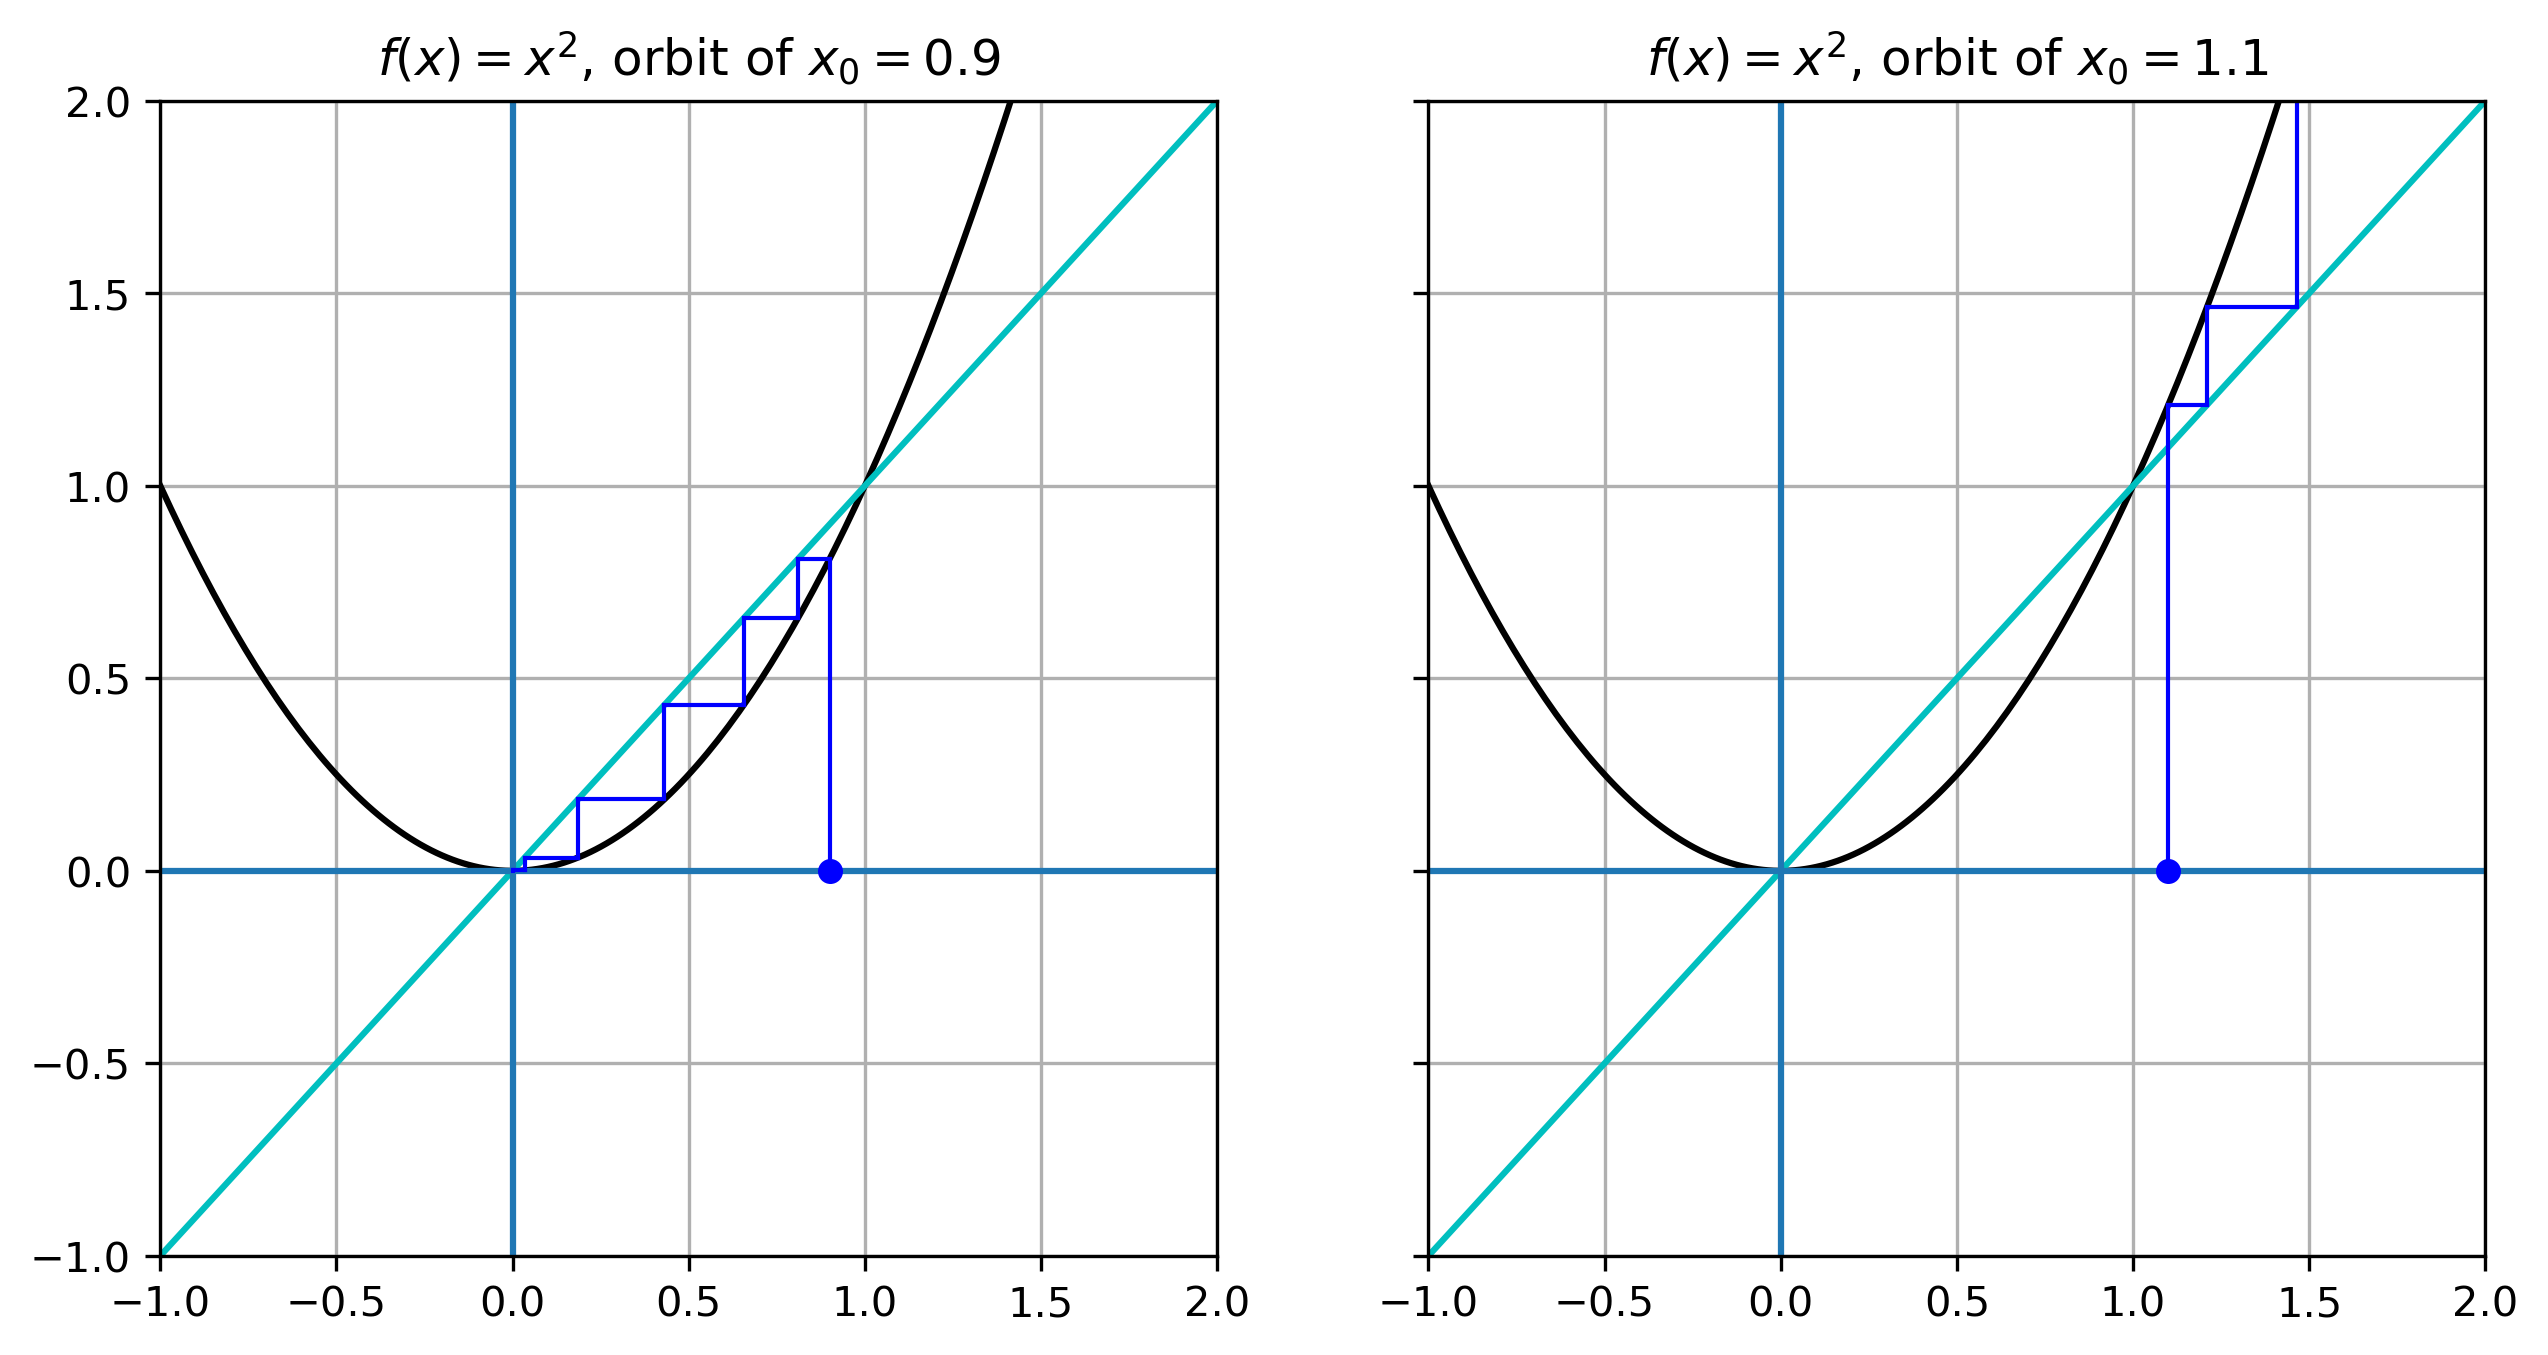

In [29]:
plt.subplots(1,2, figsize=(10,5), sharey=True)
plt.subplot(1,2,1)
x0 = 0.9
cobweb(f, x0, 10, xlim=(-1,2), ylim=(-1,2))
plt.title(f"$f(x)=x^2$, orbit of $x_0 = {x0:.1f}$")
plt.subplot(1,2,2)
x0 = 1.1
cobweb(f, 1.1, 10, xlim=(-1,2), ylim=(-1,2))
plt.title(f"$f(x)=x^2$, orbit of $x_0 = {x0:.1f}$")
plt.show()

> **Exercise**. Draw the phase portrait of the functions from the previous exercise.
>
> 1. $2x+1$
> 2. $x^2$
> 3. $x^2-2$
> 4. $x^3$

# The logistic map

The _logistic function_ $L_r(x)$ for $0 < r \leq 4$ maps the closed interval $[0,1]$ into itself, and is defined as:

\begin{equation}
L_r(x) = rx(1-x)
\end{equation}

In [30]:
def L(r, x):
    return r*x*(1-x)

This equation represents an upside-down parabola that intercepts the horizontal axis at $x=\{0, 1\}$, and has a maximum at $(1/2, r/4)$.

The _logistic map_ is the finite difference quadratic equation

\begin{equation}
x_{n+1} = rx_n(1-x_n)
\end{equation}

that provides a recursive definition of the infinite sequence $x_0, x_1, \ldots$ above. We may consider the logistic map as a mathematical description of a dynamical system that evolves at discrete times, where the system state $x_{n+1}$ at time $n+1$ depends on the previous state $x_n$. As can be seen, dependence is nonlinear, since the term $x_n$ is squared. 

The logistic map might describe the size of a population of living creatures (e.g., bacteria) replicating in an environment with finite resources. $x_n$ represents the fraction of the maximum population that is alive at time $n$. 

In case of unlimited resources, we might imagine that the rate of growth $r$ is constant, i.e., $x_{n+1} = rx_n$. In this case we see that the sequence $x_n$ grows exponentially if $r>1$, or dies out if $r<1$. If the environment can sustain a finite population, then the actual rate of growth depends both on $r$ and on the $(1 - x_n)$: if $x_n$ is small, then there are many resources available for the population to expand, while if $x_n$ is large, then there is high contention for the limited resources available and the effective growth rate is lower.

In the following we will often need to study $L(r, x)$ by fixing the value of $r$ and varying $x$. Therefore, it is useful to define a function `Lr(r0)` that accepts $r_0$ as parameter, and returns a function $L(r_0, x)$ of a single parameter $x$, where the first parameter is bound to $r_0$.

In [31]:
def Lr(r0):
    """
    Return the logistic map L(r,x) with the first parameter bound to r0.
    The result is a function L(r0, x): R -> R.
    """
    return (lambda x : L(r0, x))

Let us visualize the orbit of $x_0 = 0.1$ with $r=2.8$. This time we plot the points of the orbits $x_k$ as a function of $k$, to better understand the limiting behavior.

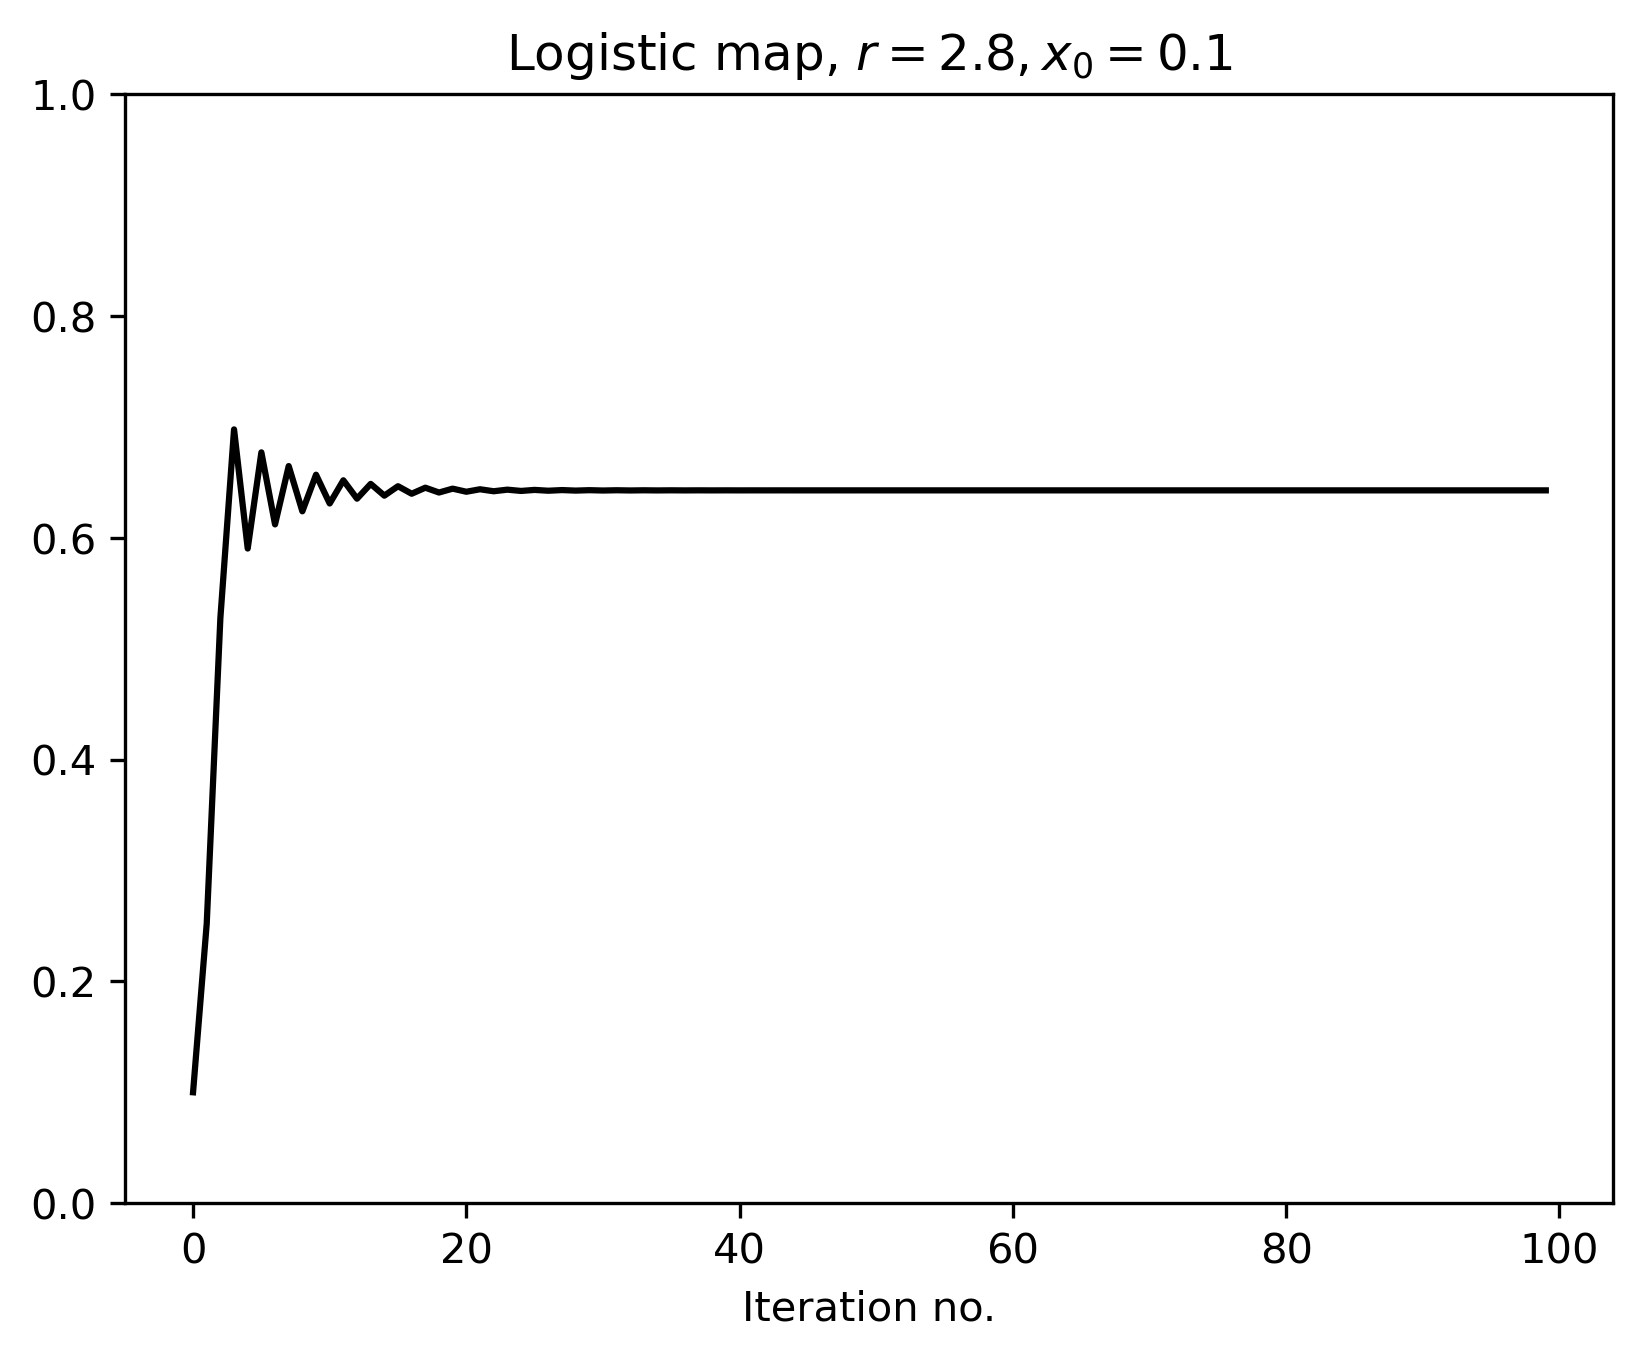

In [32]:
x0 = 0.1
r  = 2.8

orb = orbit(Lr(r), x0, 100)

plt.plot(orb, 'k')
plt.ylim(0,1)
plt.title(f"Logistic map, $r={r:.1f}, x_0={x0:.1f}$")
plt.xlabel("Iteration no.")
plt.show()

### Fixed points of the logistic map

The fixed points of the logistic map are the solutions of the quadratic equation $rx(1-x) = x$. A bit of algebra yields:

\begin{align*}
rx(1-x)       &= x \\
rx - rx^2     &= x \\
rx^2 + (1-r)x &= 0\\
x(rx + (1-r)) &= 0
\end{align*}

that has two solutions $x=0$ and $x = \frac{r-1}{r}$; note that this last fixed point is outside the domain of $L_r(x)$ if $r<1$.

Let us use graphical analysis to find the fixed points of $L_r(x)$ for different values of $r$.

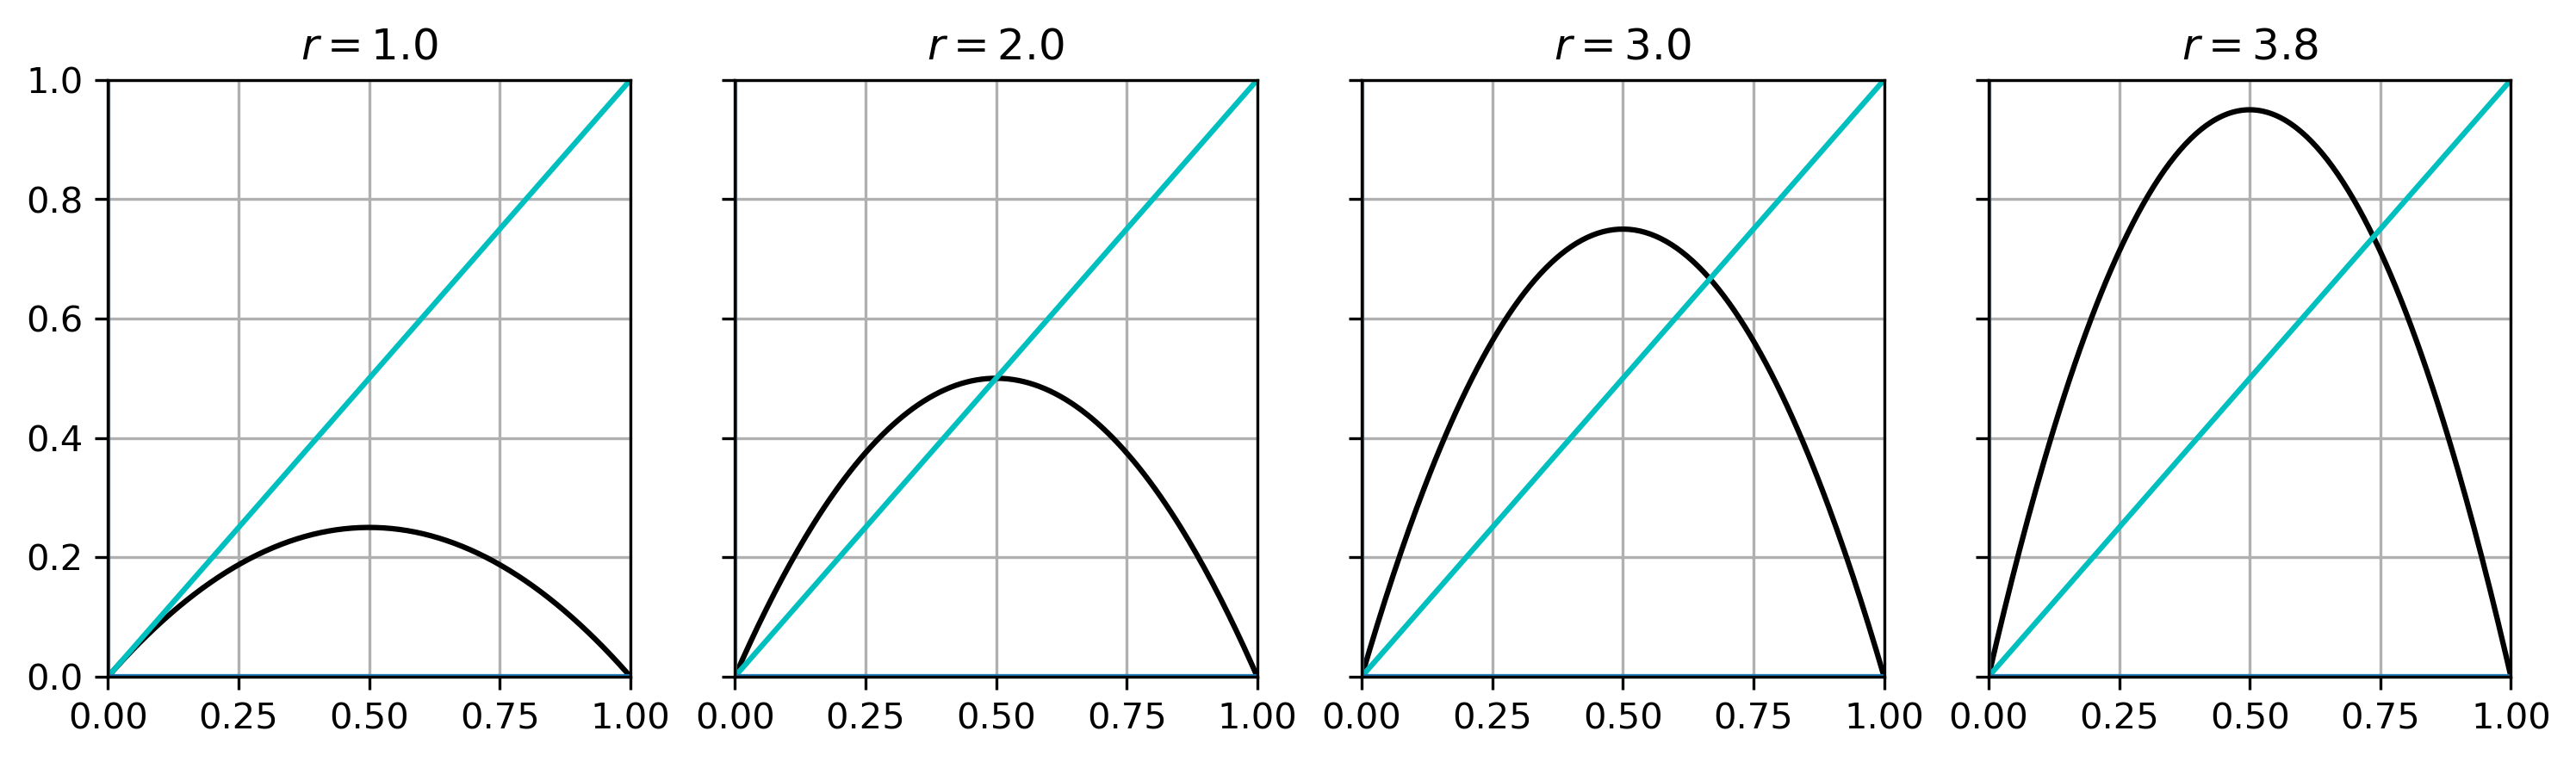

In [33]:
allr = [1, 2, 3, 3.8]

plt.subplots(1, len(allr), figsize=(12,3), sharey=True)
for i,r in enumerate(allr, start=1):
    plt.subplot(1, len(allr), i)
    plot_fixed_points(Lr(r), title=f"$r={r:.1f}$") 

### Orbits of the logistic map

We now turn our attention to the following question: given a function $f(x)$ with $k$ fixed points $\bar{x}_0, \bar{x}_1, \ldots, \bar{x}_{k-1}$, which are the initial points whose orbits converge towards each one? Do all initial points converge towards a fixed point?

We define the _basin of attraction_ $B_f(\bar{x})$ for a fixed point $\bar{x}$ of $f$ as the set of points whose orbits converge towards $\bar{x}$. More precisely:

\begin{align}
B_f(\bar{x}) &= \{ x\ |\ \lim_{n \rightarrow \infty} f^n(x) = \bar{x}\}
\end{align}

For one-dimensional functions such as the logistic map, there exists a surprisingly simple graphical way to study the basin of attraction, called _cobweb plot_. We start by plotting the function $y = f(x)$ and the bisector $y=x$. To visualize the orbit of some initial value $x_0$, do the following:

1. Find the point $x_0$ on the horizontal axis.
2. Draw a vertical segment to the function.
3. Draw a horizontal segment to the diagonal.
4. Repeat from 2.

As an example, suppose that we want to study the orbit of point $0.1, 0.4, 0.9$ under repeated application of the logistic map for $r=2.5$.

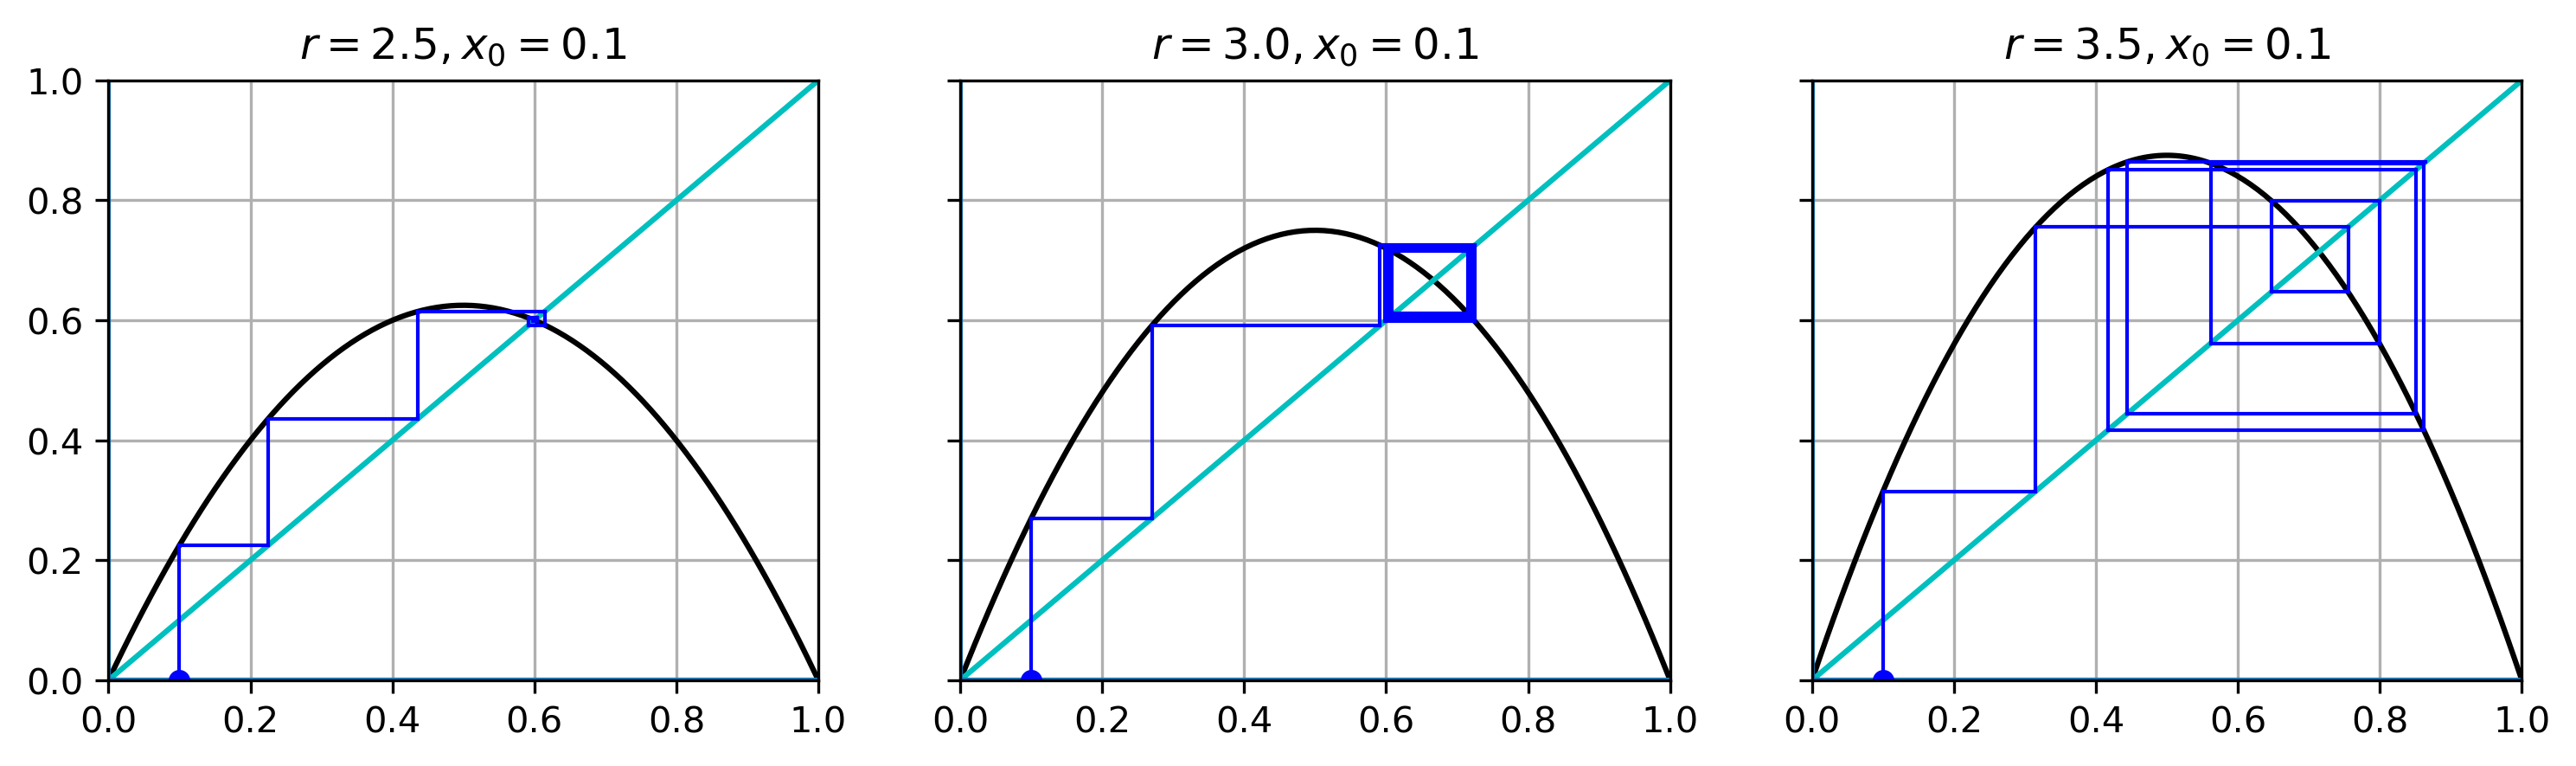

In [34]:
x0 = 0.1
rs = [2.5, 3.0, 3.5]
plt.subplots(1, len(rs), figsize=(12,3), sharey=True)
for i,r in enumerate(rs, start=1):
    plt.subplot(1, len(rs), i)
    cobweb(Lr(r), x0=x0, n=10, title=f"$r={r:.1f}, x_0={x0:.1f}$")

## Periodic orbits

Convergence towards a fixed point is by no means the only possible behavior. For example, let us see what happens when $r=3.2$.

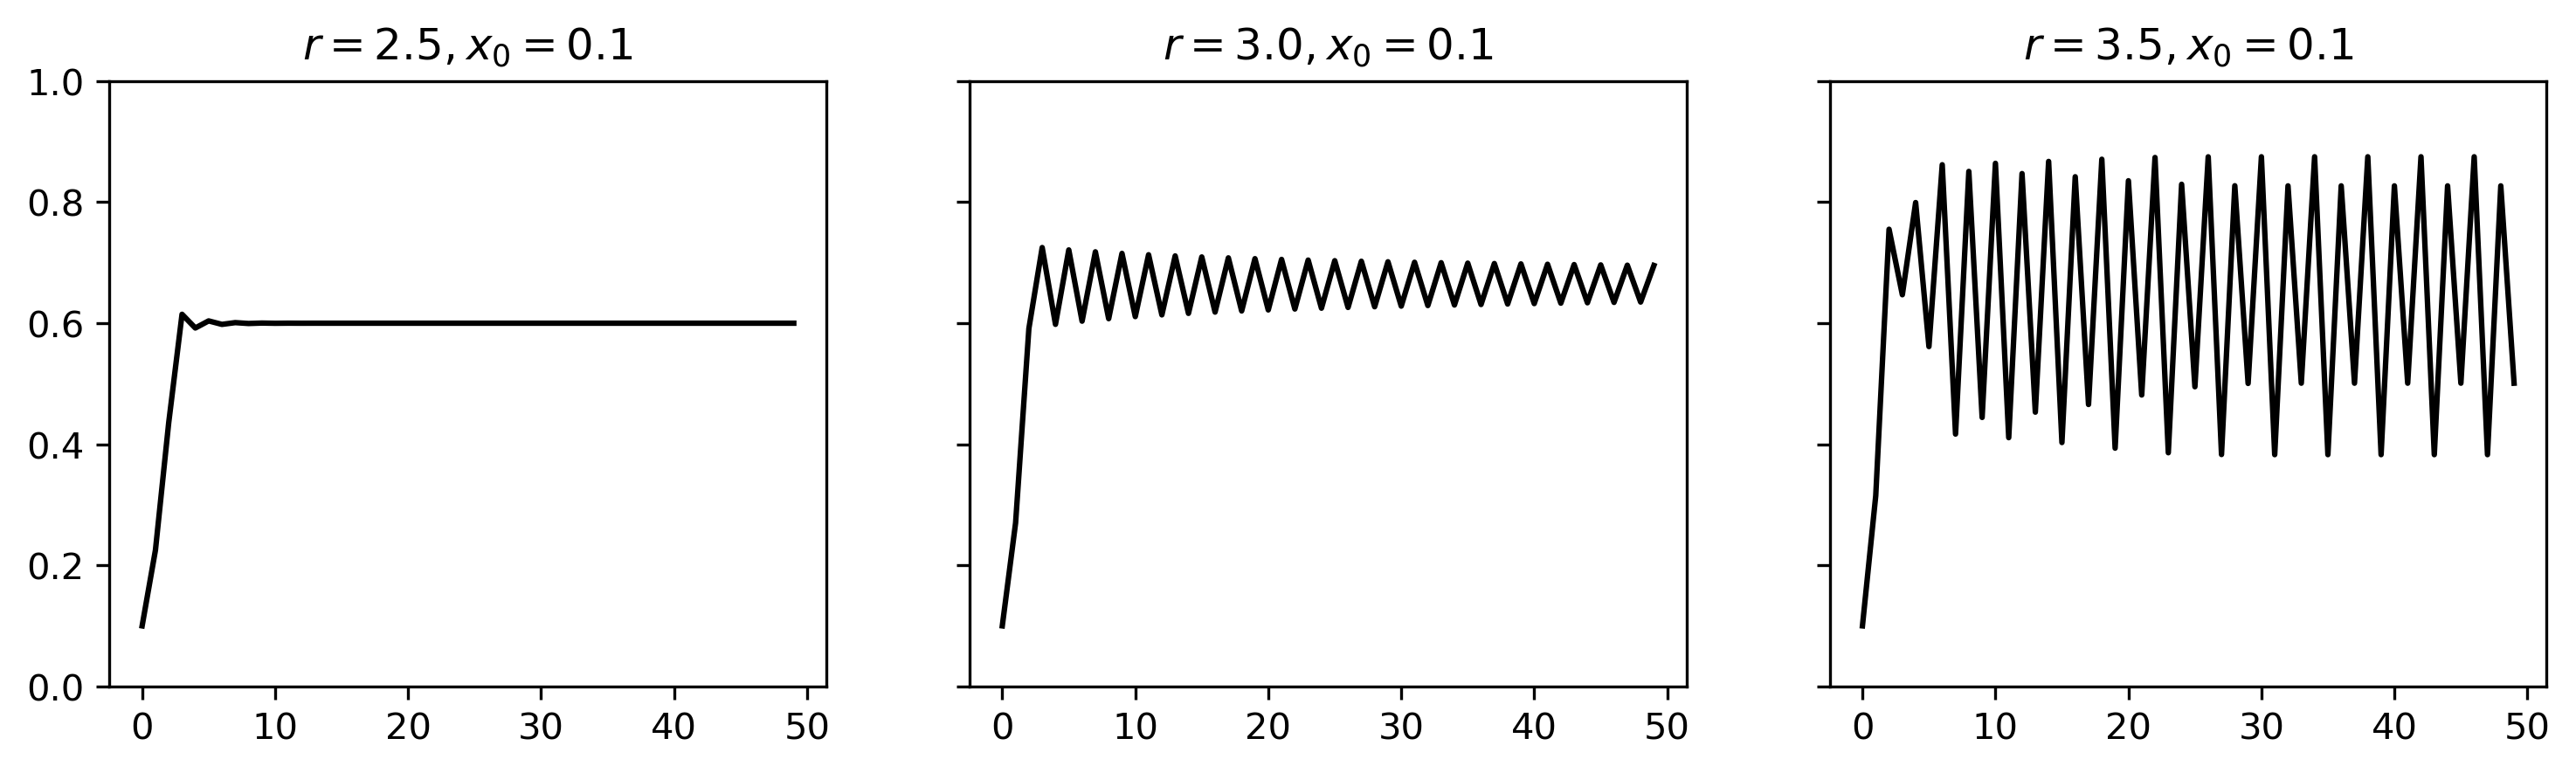

In [35]:
plt.subplots(1, len(rs), figsize=(12,3), sharey=True)
for i,r in enumerate(rs, start=1):
    plt.subplot(1, len(rs), i)
    orb = orbit(Lr(r), x0, 50)
    plt.plot(orb, 'k')
    plt.ylim(0,1)
    plt.title(f"$r={r:.1f}, x_0={x0:.1f}$")
plt.show()

Here we see that the orbit of $x_0$, after the initial transient, oscillates between two values; note that this happens regardless of the initial choice of $x_0$, except when $x_0 = \frac{r-1}{r}$ which is the fixed point. 

This oscillating behavior corresponds to an _orbit of period two_ of $f$. Two values $s, t$ form an orbit of period two if:

\begin{align*}
f(s) &= t \\
f(t) &= s
\end{align*}

which is precisely what we observe in the plot above. 

We observe that $s$ belongs to an orbit of period two if and only if $s$ is a fixed point for the function $f^2(x) = f(f(x))$ and $s$ is not a fixed point for $f$. Indeed, if $s$ belongs to a period-two orbit, then by definition $f(f(s)) = s$, which implies that $s$ is a fixed point for $f^2$. On the other hand, if $s$ is a fixed point for $f^2$, let $t = f(s)$. Then:

\begin{align*}
f(s) &= t\\
f(t) &= f(f(s)) = s
\end{align*}

meaning that $s,t$ are a period-two orbit for $f$.

Computing the fixed points for $f^2$ means solving $f(f(x)) = x$ which is not easy. However, we can apply graphical analysis to look for the intersections of the curves $y = f^2(x)$ and $y=x$.

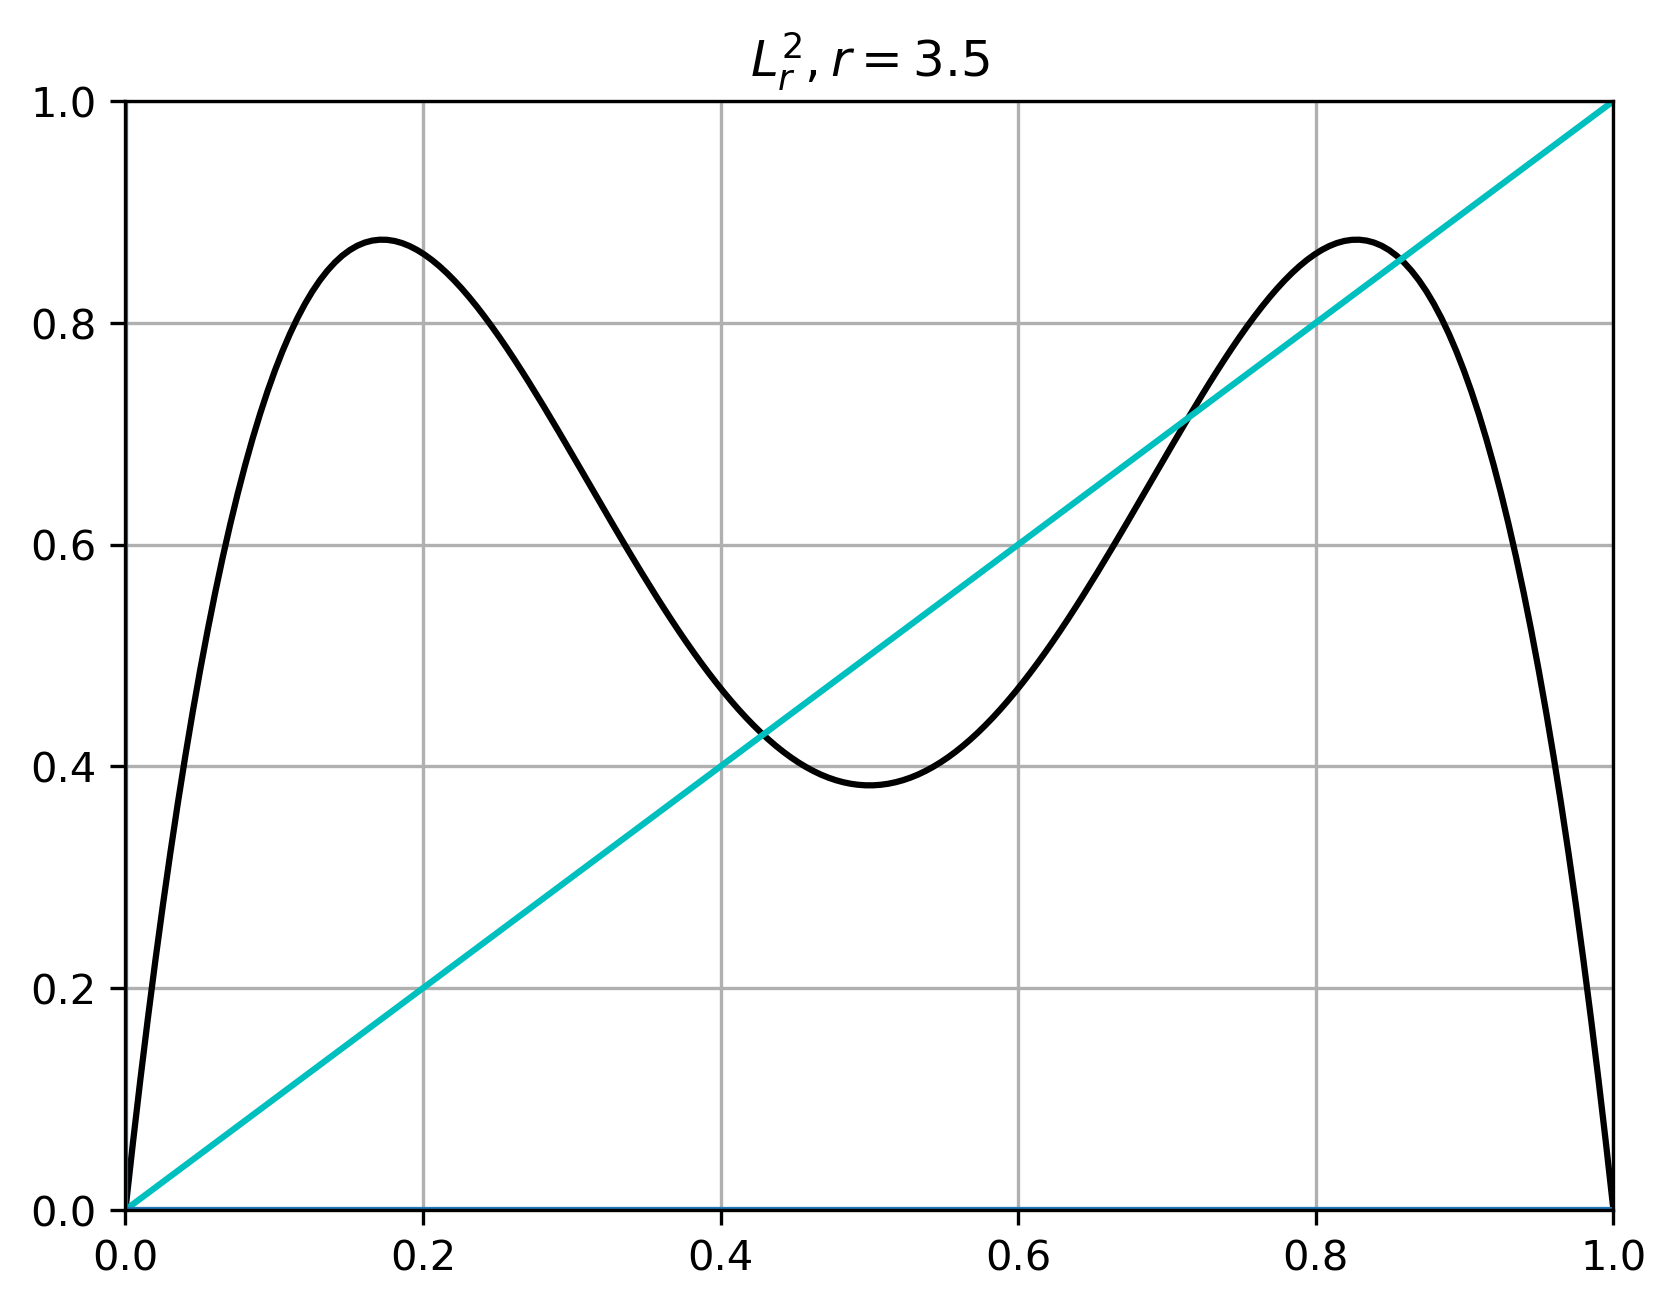

In [42]:
r = 3.5
plot_fixed_points(lambda x: L(r, L(r, x)), title=f"$L_r^2, r={r:.1f}$")

The graphical analysis reveals that, with the current choice of $r$, $f^2(x)$ has four fixed points that we call $a, b, c, d$ from left to right. It is easy to see that $a=0$; also, a fixed point for $f$ is also a fixed point for $f^2$, so we have that $c=\frac{r-1}{r}$.

In [37]:
c = (r-1)/r
print(c)

0.7142857142857143


In [38]:
L(r, L(r, c))

0.7142857142857144

The values of $b$ and $d$ must be computed numerically; we see that $b$ is somewhat less than $0.6$ and $d$ is somewhat more than $0.8$.

We can generalize the observation above by stating that $x$ belongs to a period-$k$ orbit if it is a fixed point of $f^k(x)$. 

Function `applyf(f, n)` returns a function with a single parameter that corresponds to $f^n$. 

In [39]:
def applyn(f, n):
    """ 
    Return a function of a single parameter that, when evaluated,
    computes f^n(x), i.e., f(f(...f(x)...)). f^0(x) is the
    identity function f^0(x) = x for any x.
    """
    if n == 0:
        return lambda y: y
    else:
        return lambda y: f(applyn(f, n-1)(y))

We can not study the fixed points of the first iterates of the logistic map.

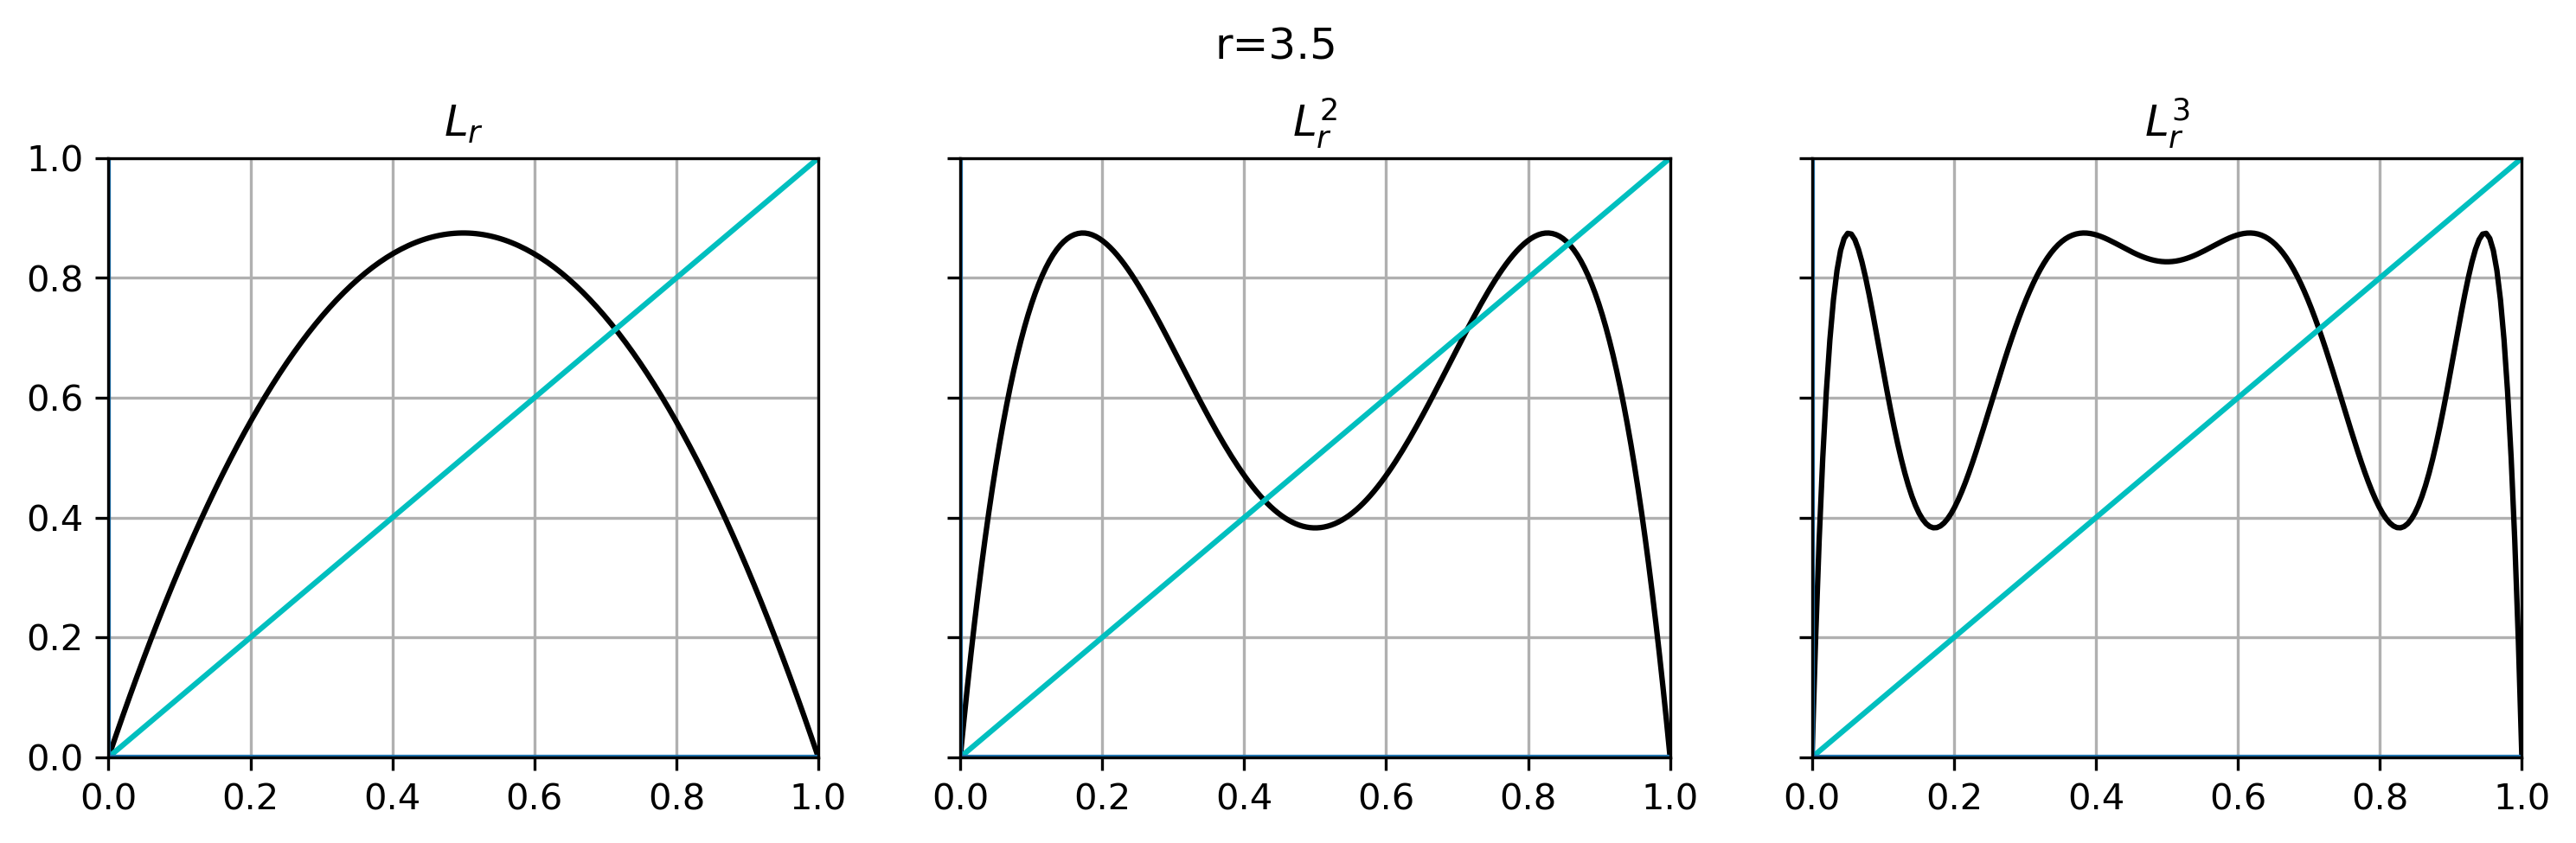

In [41]:
r = 3.5
plt.subplots(1, 3, figsize=(12,3), sharey=True)
plt.subplot(1,3,1)
plot_fixed_points(Lr(r), title="$L_r$")
plt.subplot(1,3,2)
plot_fixed_points(applyn(Lr(r), 2), title="$L_r^2$")
plt.subplot(1,3,3)
plot_fixed_points(applyn(Lr(r), 3), title="$L_r^3$")
plt.suptitle(f"r={r:.1f}", y=1.05);

We see that $f$ has two fixed points, $f^2$ has four (two of period two, and two of period one that are the same as $f$), and $f^3$ has two fixed points, both of which are actually fixed points of $f$. Therefore, with the current choice of $r$, there are two fixed points and two period-two orbits. Note that our analysis does not depend on the initial value $x_0$.

> **Exercise**: The _tent map_ $T: [0,1] \rightarrow [0,1]$ is defined as follows:
>
> \begin{equation}
T(x) = \begin{cases}
2x & \mbox{if}\ x < 0.5\\
2-2x & \mbox{otherwise}
\end{cases}
\end{equation}
>
> Use graphical analysis to compute the number of fixed points of $T^k(x)$.

In [22]:
def T(x):
    return (2*x if x < 0.5 else 2-2*x)

We can study the fixed points of $T(x)$, $T^2(x) = T(T(x))$, $T^3(x) = T(T(T(x)))$.

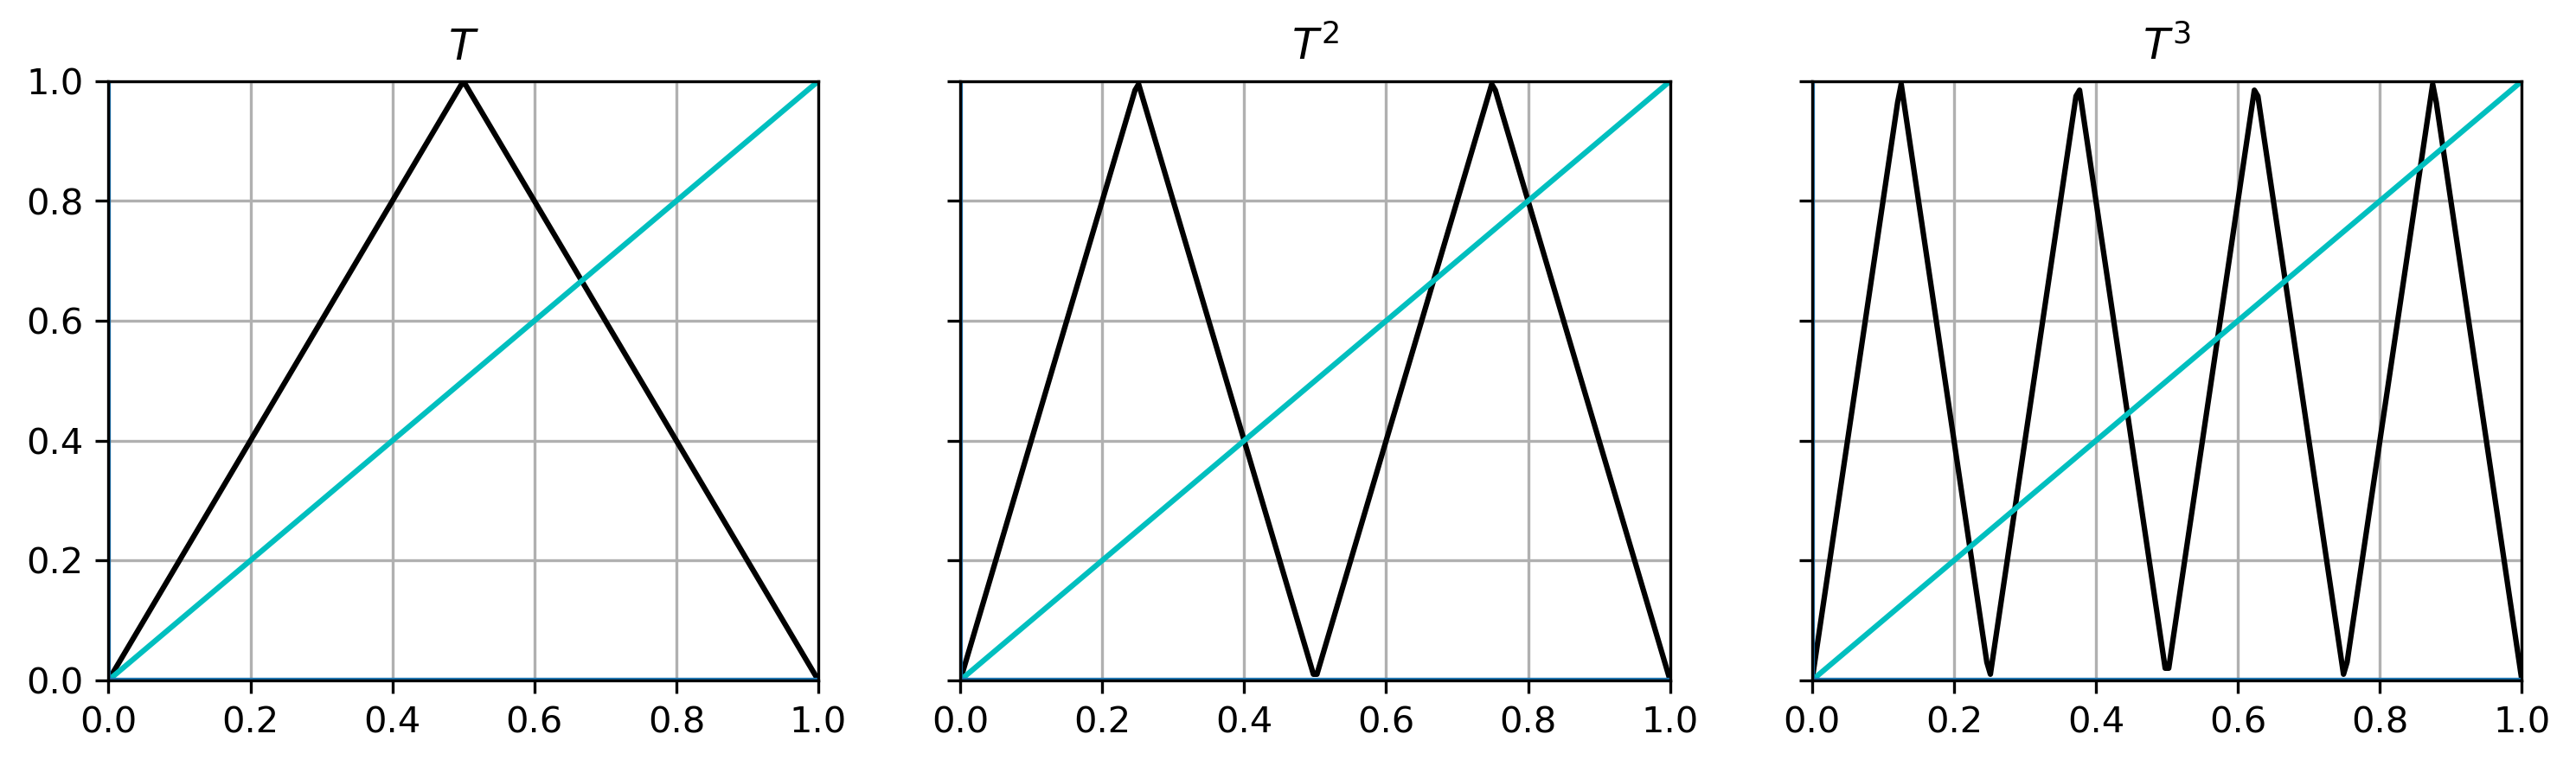

In [23]:
plt.subplots(1, 3, figsize=(12,3), sharey=True)
plt.subplot(1,3,1)
plot_fixed_points(T, title = f"$T$")
plt.subplot(1,3,2)
plot_fixed_points(applyn(T, 2), title = f"$T^2$")
plt.subplot(1,3,3)
plot_fixed_points(applyn(T, 3), title = f"$T^3$")

We observe that $T^k(x)$ has $2^k$ fixed points.

In [24]:
skip  = 900      # how many points to skip
keep  = 100      # how many points to keep
x0    = 0.1
r0    = 2.8      # Try 2.8, 2.99, 3.01, 3.5, 3.56, 3.8, 3.83(<- period three)
bounds = (2.5, 4.0) # Try (3.82, 3.86) for a period-three cycle

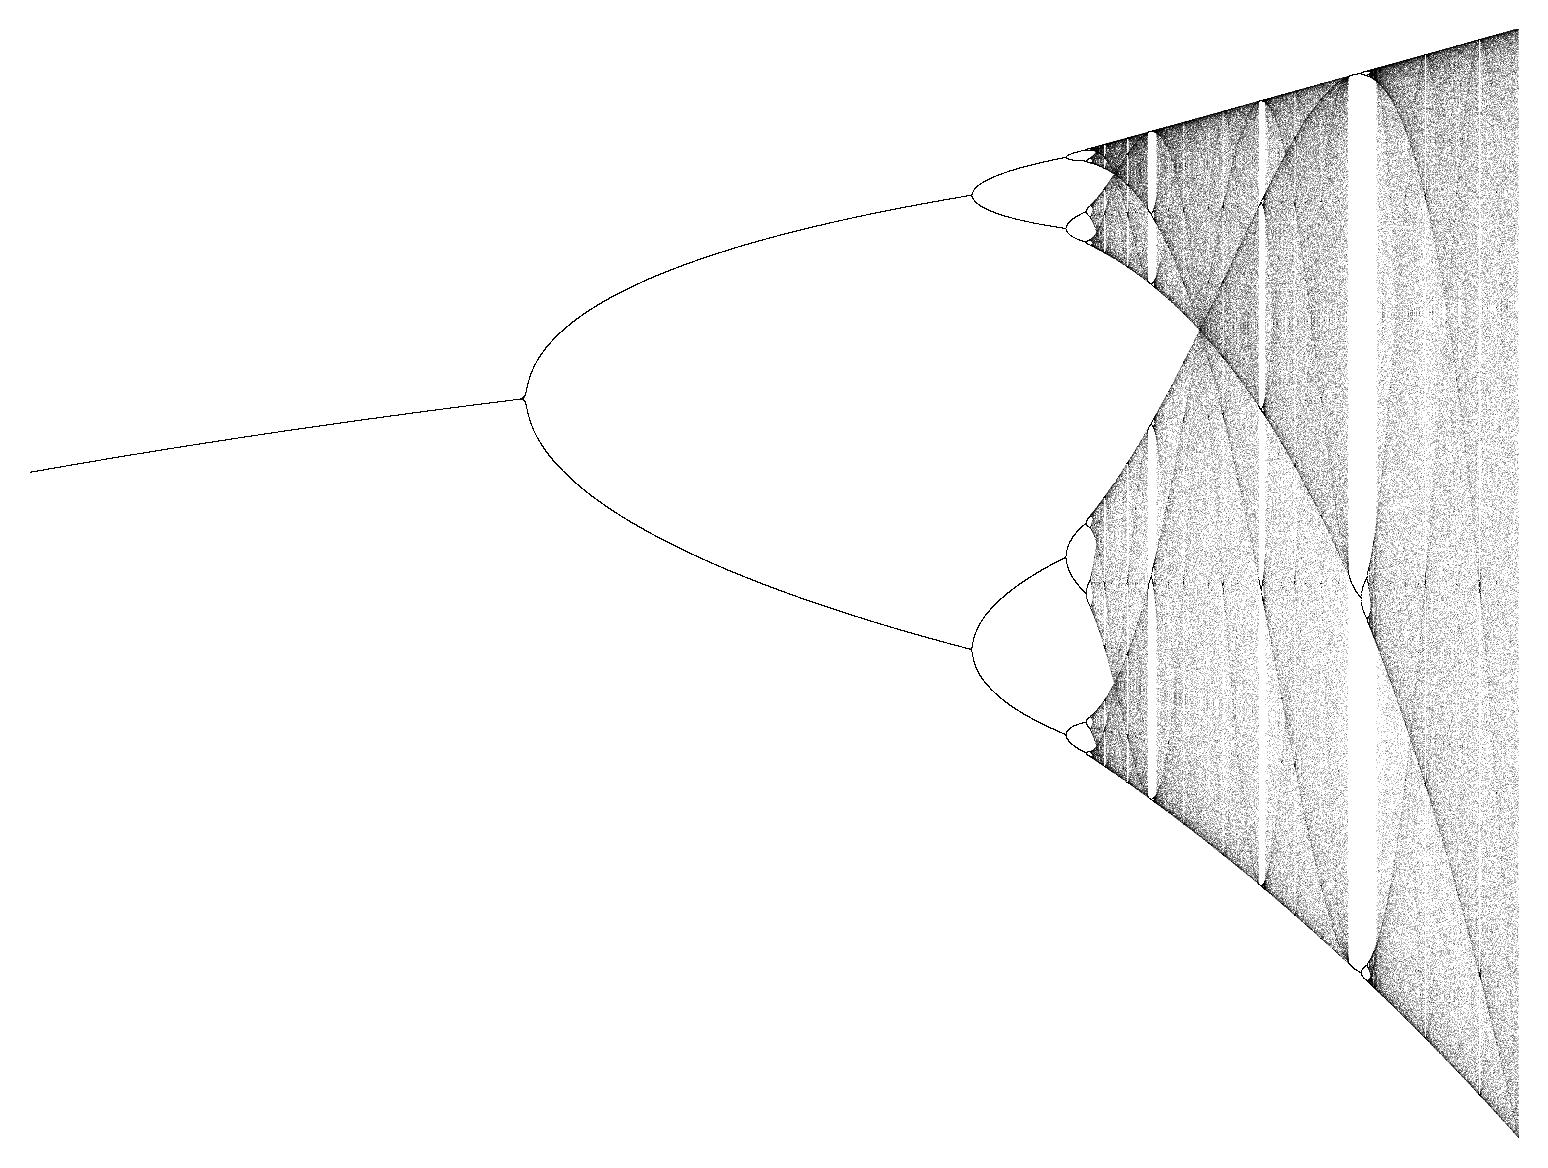

In [35]:
rs = np.linspace(bounds[0], bounds[1], 10000)
for r in rs:
    values = list(it.islice(iterate(Lr(r), x0), skip, skip+keep))
    plt.plot(np.repeat(r, len(values)), values, ',k', alpha=.25)
plt.xlabel("k")
#plt.title(f"Orbits of {x0:.2f} after {skip} iterations")
plt.axis("off")
plt.gca().margins(0)
plt.savefig('fig-tree.png', bbox_inches='tight', pad_inches=0)
plt.show()

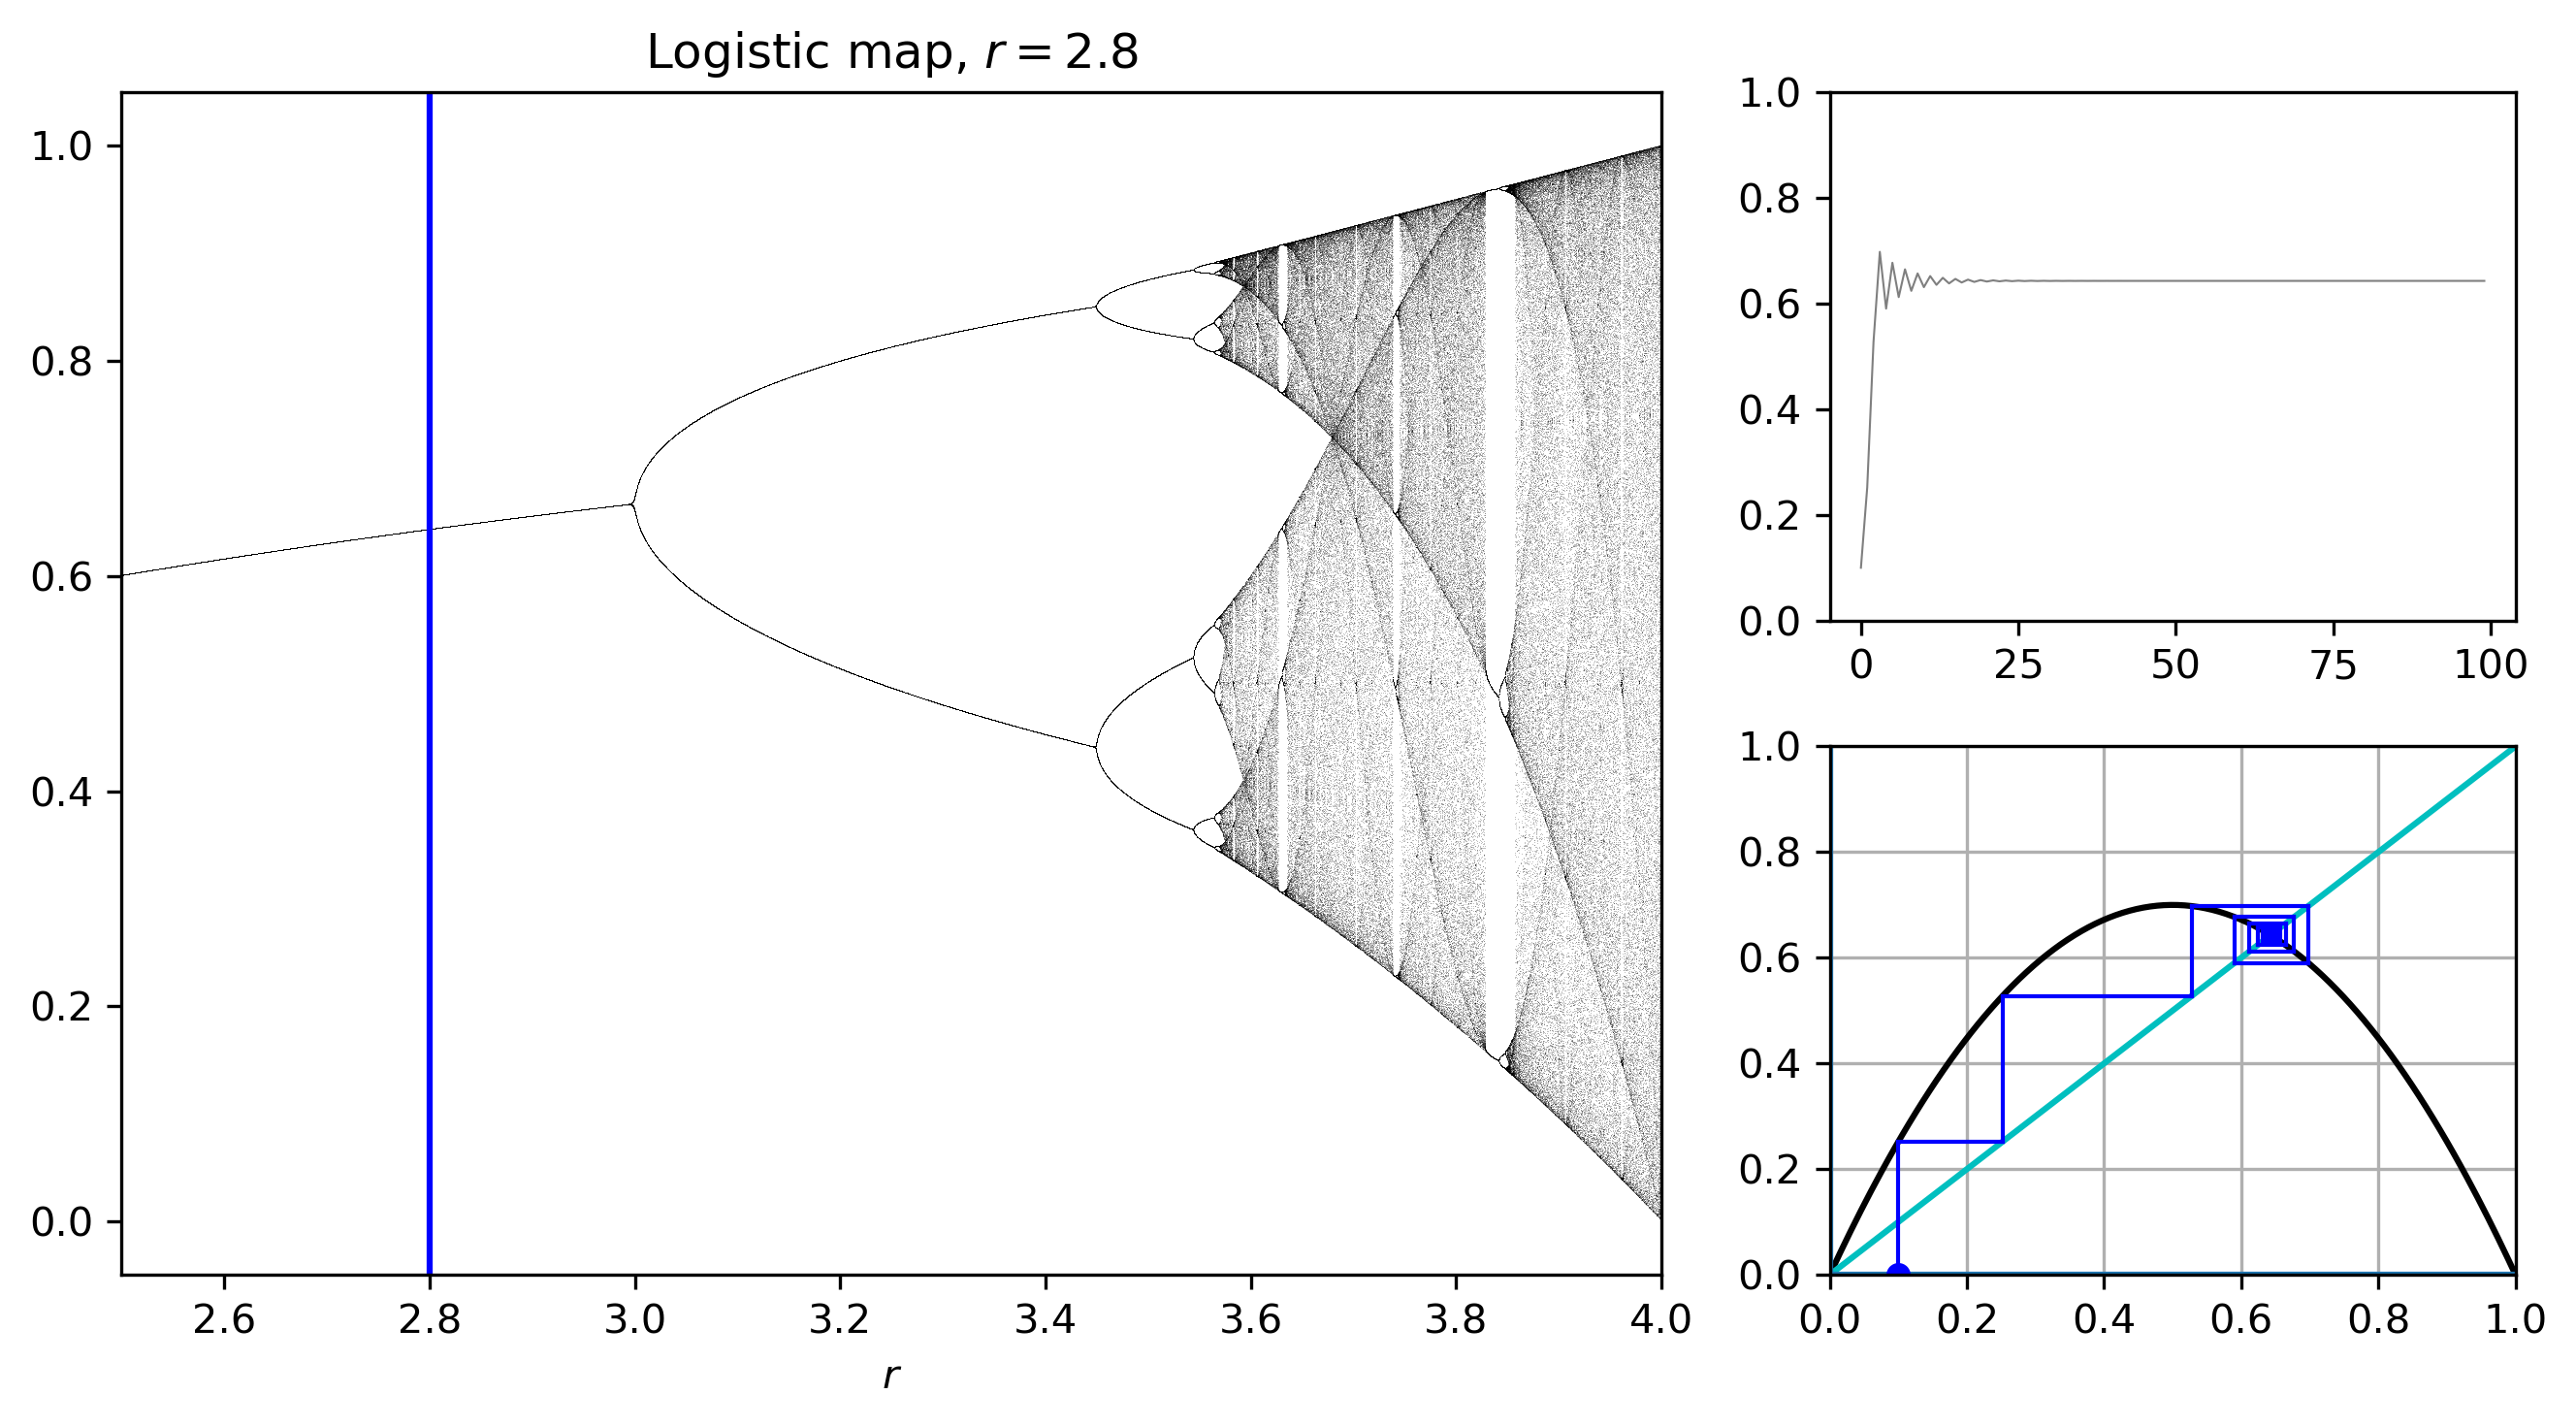

In [26]:
# Prepare the plot layout
fig = plt.figure(figsize=(9, 5), layout="constrained")
spec = fig.add_gridspec(2, 3)
bifurcation_ax = fig.add_subplot(spec[:, 0:2])
iterations_ax = fig.add_subplot(spec[0,2])
cobweb_ax = fig.add_subplot(spec[1,2])

# Plot the bifurcation diagram
plt.sca(bifurcation_ax)
rs = np.linspace(bounds[0], bounds[1], 10000)
for r in rs:
    values = list(it.islice(iterate(Lr(r), x0), skip, skip+keep))
    plt.plot(np.repeat(r, len(values)), values, ',k', alpha=.25)
plt.axvline(x=r0, color='b')
plt.xlabel("$r$")
plt.xlim(bounds)
plt.title(f"Logistic map, $r={r0:.1f}$")

# Plot the orbit
plt.sca(iterations_ax)
logistic_sequence = list(it.islice(iterate(Lr(r0), x0), 100))
plt.plot(logistic_sequence, '-k', lw=0.5, alpha=0.5)
# To better visualize the orbit, replace the two lines above with
#logistic_sequence = list(it.islice(logistic_gen(r0, x0), 5000))
#plt.plot(logistic_sequence, '.k', ms=0.2, alpha=0.5)
plt.ylim(0,1)

# Cobweb plot
plt.sca(cobweb_ax)
cobweb(Lr(r0), x0=x0, n=30)

plt.tight_layout()
plt.show()

# References

- https://github.com/ipython-books/cookbook-2nd-code/tree/master/chapter12_deterministic

- Cyrille Rossant, _IPython Cookbook, Second Edition_, a guide to numerical computing and data science in the Jupyter Notebook. [12.1. Plotting the bifurcation diagram of a chaotic dynamical system](https://ipython-books.github.io/121-plotting-the-bifurcation-diagram-of-a-chaotic-dynamical-system/)